DONE @ (102942)!


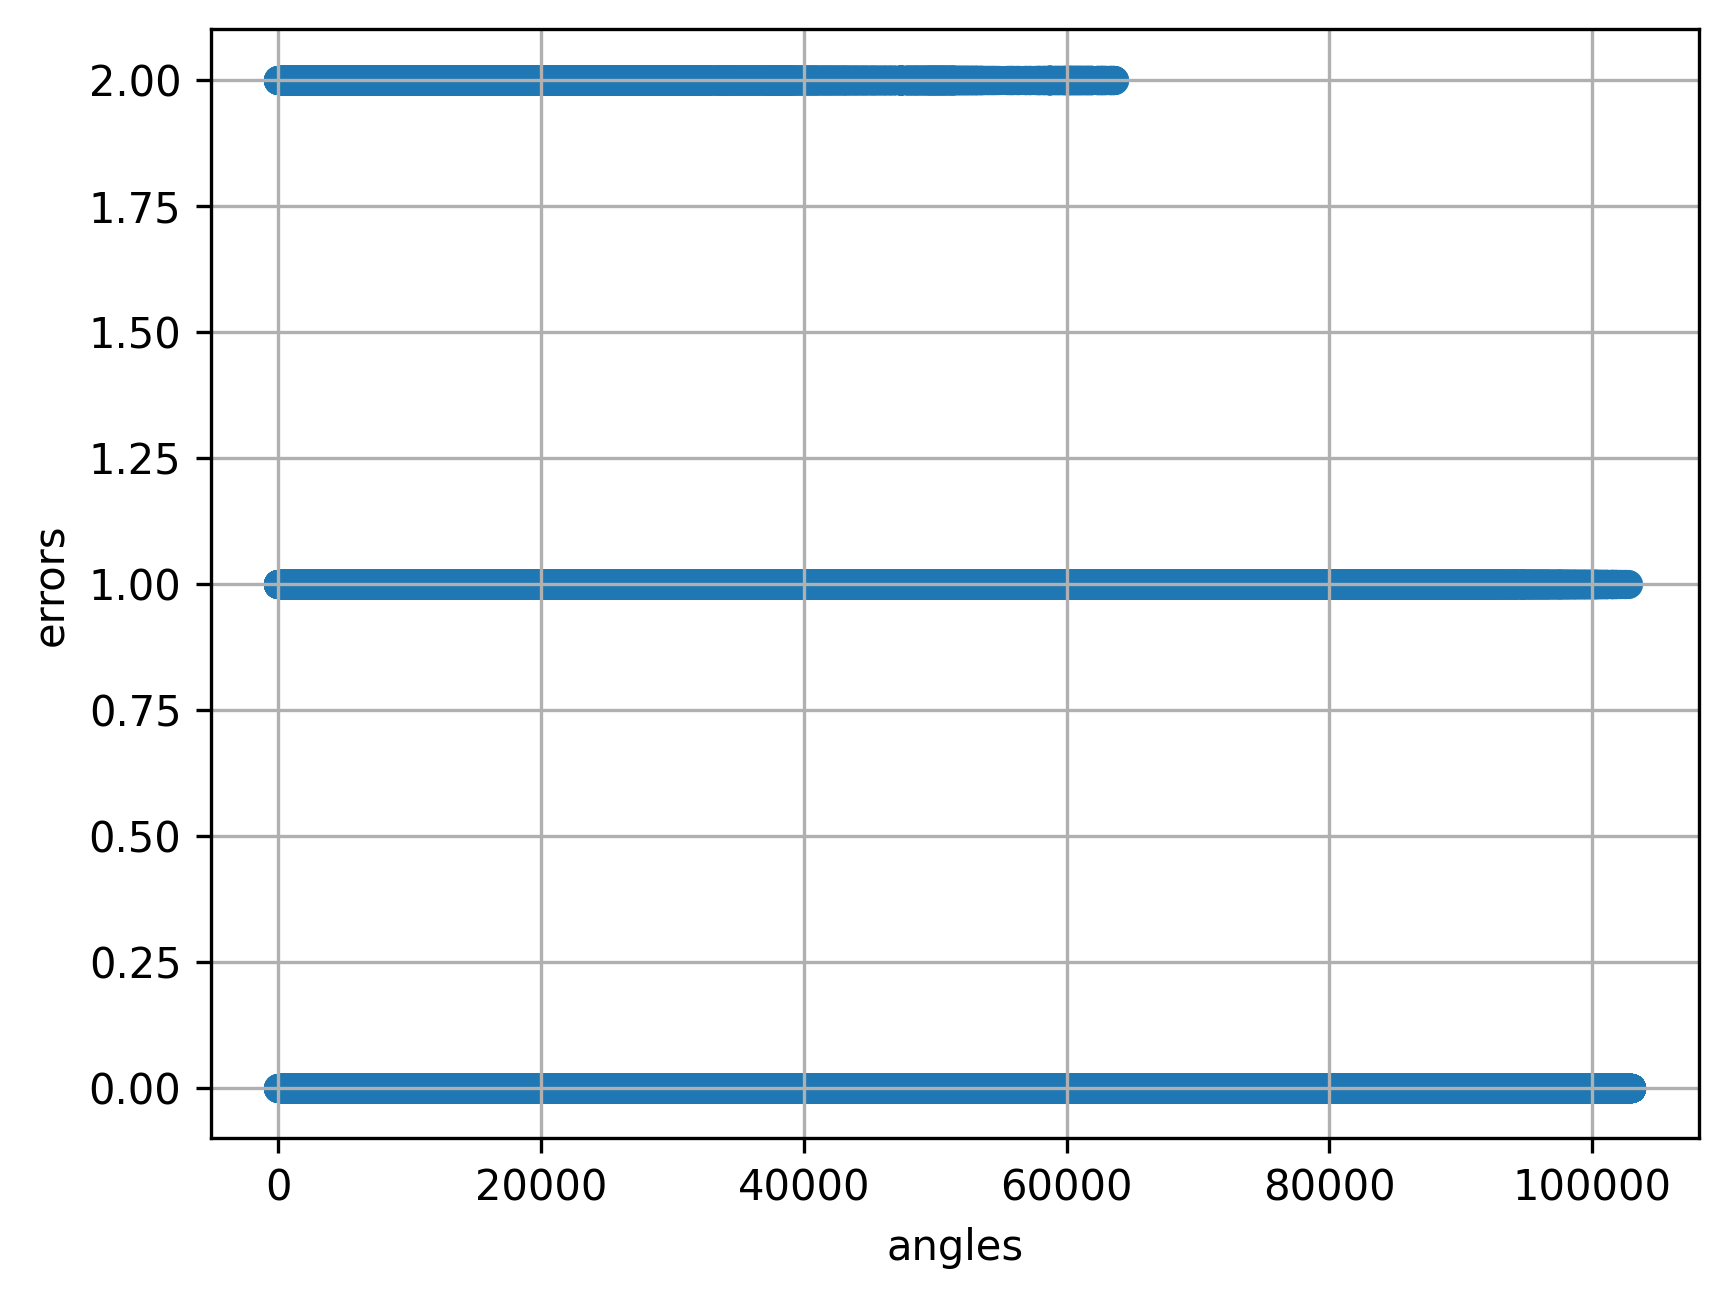

In [ ]:
import math
import random
from math import floor
import matplotlib.pyplot as plt

# parameter
FLAG_FULL_PRECISION = 1
NUMB_ITER = 16
DATA_INT_WD = 1
DATA_FRC_WD = 16
DATA_WD = DATA_INT_WD + DATA_FRC_WD

# angles
if FLAG_FULL_PRECISION:
    ANGLES = [math.atan(2**(-i)) for i in range(NUMB_ITER)]
else:
    1    #!!! TO BE ADDED

# K
K = 1
for i in range(NUMB_ITER):
    K *= math.cos(ANGLES[i])
if FLAG_FULL_PRECISION:
    1    # do nothing
else:
    1    #!!! TO BE ADDED

# sin_cordic
def sin_cordic(theta):
    x = K
    y = 0
    z = theta
    for i in range(NUMB_ITER):
        d = 1 if z >= 0 else -1
        if FLAG_FULL_PRECISION:
            x_temp = x * (2 ** (-i))
            y_temp = y * (2 ** (-i))
        else:
            1    #!!! TO BE ADDED
        x_next = x - d * y_temp
        y_next = y + d * x_temp
        z_next = z - d * ANGLES[i]
        x = x_next
        y = y_next
        z = z_next
    return y

# main
fpt_i = open('SIN_DAT_I_S0I1F16.dat', 'w')
fpt_o = open('SIN_DAT_O_S0I1F16.dat', 'w')
errors = []
angles = range(floor(math.pi / 2 * (2 ** DATA_FRC_WD)))
for theta in angles:
    result_target = floor(  math.sin(theta / (2 ** DATA_FRC_WD)) * (2 ** DATA_FRC_WD) + 0.5)
    result        = floor(sin_cordic(theta / (2 ** DATA_FRC_WD)) * (2 ** DATA_FRC_WD) + 0.5)
    errors.append(abs(result - result_target))
    fpt_i.write("{:x}\n".format(theta              ))
    fpt_o.write("{:x}\n".format(result & 0xffffffff))
fpt_i.close
fpt_o.close

print(f"DONE @ ({theta})!")

plt.rcParams['figure.dpi'] = 300
plt.scatter(angles, errors)
plt.xlabel('angles')
plt.ylabel('errors')
plt.grid(True)
plt.show()